In [ ]:
import nltk.corpus
nltk.download('stopwords')
from nltk.corpus import stopwords
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

from tensorflow import keras
import seaborn as sns; sns.set()
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib as mpl
import tensorflow as tf
import cv2
import os
from keras.optimizers import Adam
from tensorflow.keras.layers import Dense
import tensorflow_hub as hub

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/Memoria_Risk_Classification/Datasets/'

df_tos = pd.read_csv(path + 'Full_TOSDR_2023.csv')

# df_tos.rename(columns = {'Service':'service','QouteText':'text', 'Point':'label'}, inplace = True)
df_tos['text'] = df_tos['text'].fillna(' ')
print(df_tos.shape)
print(df_tos['label'].value_counts())
df_tos[['text', 'label']].head(3)

(4450, 6)
secondary    1803
warning      1404
success      1106
danger        137
Name: label, dtype: int64


,text,label
0,any errors or defects will be corrected\r\nTer...,warning
1,The Change Log section below is not a part of ...,success
2,"<p>In an event of a breach, we recognize our r...",success


In [ ]:
duplicate = df_tos[df_tos.duplicated('text')]
duplicate.head(5)

,Unnamed: 0,service,privacy_text,case_link,label,text
847,847,crunchyroll,Failure to enforce any provision of the Terms ...,https://edit.tosdr.org/points/9465,secondary,"If we fail to enforce any of these Terms, it w..."
974,974,discord,The service can read your private messages,https://edit.tosdr.org/points/9070,danger,Information we collect may include but not be ...
975,975,discord,The service can delete specific content withou...,https://edit.tosdr.org/points/11419,danger,The Company reserves the right to remove and p...
976,976,discord,This service keeps user logs for an undefined ...,https://edit.tosdr.org/points/11462,warning,We generally retain personal data for so long ...
977,977,discord,This service may keep personal data after a re...,https://edit.tosdr.org/points/11463,warning,"To dispose of personal data, we may anonymize ..."


In [ ]:
df_tos = df_tos.drop_duplicates(subset=['text'])

In [ ]:
df_tos = df_tos.dropna(subset=['text'])

In [ ]:
df_tos.shape

(4013, 6)

In [ ]:
df_tos['len_seq'] = df_tos['text'].apply(lambda x: len(x.split(' ')))

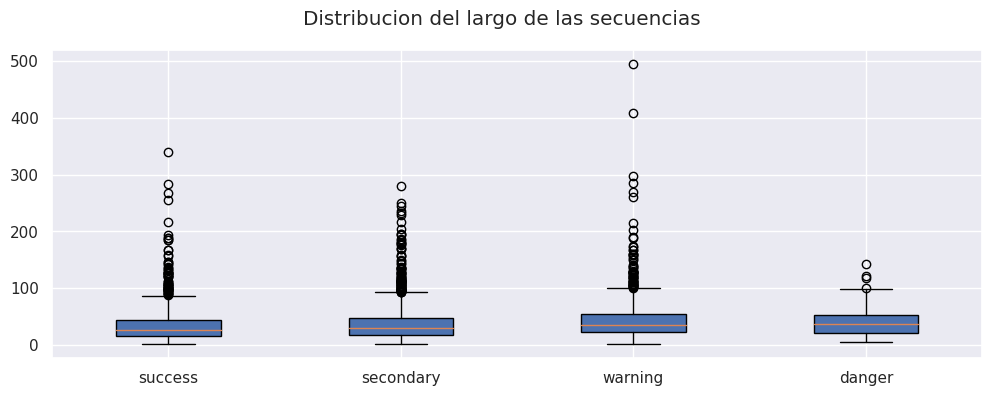

In [ ]:
clases = ['success','secondary', 'warning', 'danger']

data = []

for clase in clases:
  data_class = df_tos[(df_tos['label'] == clase) & (df_tos['len_seq'] <= 512)]['len_seq'].values
  data.append(data_class)

fig, ax = plt.subplots(figsize=(12,4))
fig.suptitle("Distribucion del largo de las secuencias")
# ax[0].hist(seq_lens)
ax.boxplot(data, patch_artist=True,labels=clases)
plt.show()

280
143
339
495


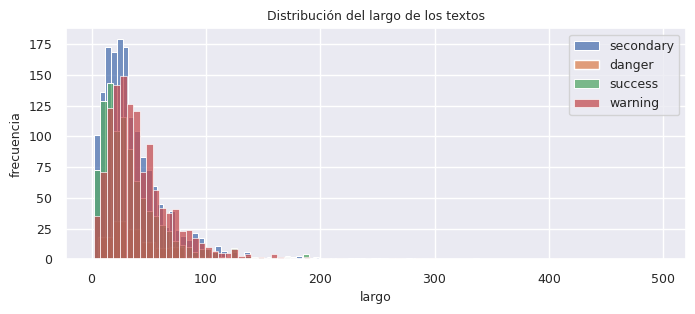

In [ ]:
fig, ax = plt.subplots(figsize=(8,3),nrows=1)
clases = ['secondary', 'danger', 'success', 'warning']
for clase in clases:
  data = df_tos[df_tos['label']==clase]
  lengths = data[data['len_seq'] <= 512]['len_seq'].values
  print(lengths.max())
  sns.histplot(lengths,label=clase)

ax.set_title('Distribución del largo de los textos',fontsize=9)
ax.set_xlabel("largo",fontsize=9)
ax.set_ylabel("frecuencia",fontsize=9)
ax.tick_params(axis='both', which='major', labelsize=9)
ax.legend(fontsize=9)
plt.show()

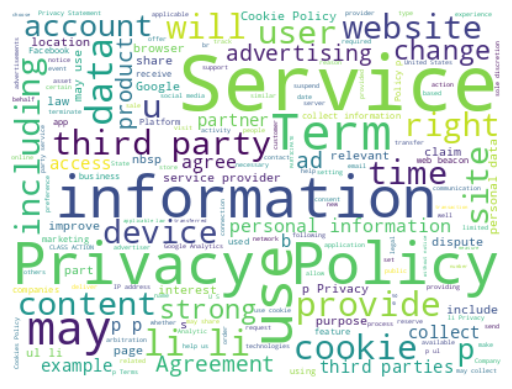

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

texto = " ".join(df_tos[df_tos['label'] == 'warning']['text'].values)

wc = WordCloud(width = 400, height = 300, background_color = "white")
wc.generate(texto)

plt.axis("off")
plt.imshow(wc, interpolation = "bilinear")

# plt.show()

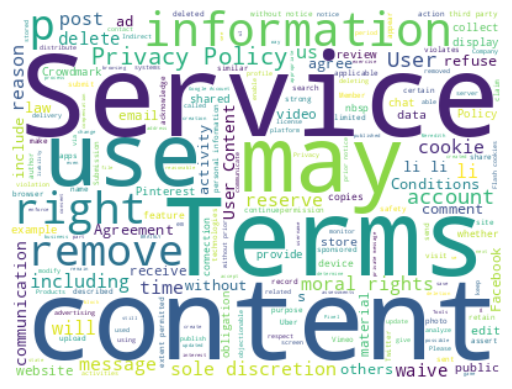

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

texto = " ".join(df_tos[df_tos['label'] == 'danger']['text'].values)

wc = WordCloud(width = 400, height = 300, background_color = "white")
wc.generate(texto)

plt.axis("off")
plt.imshow(wc, interpolation = "bilinear")

# plt.show()

In [ ]:
# # df_tos['label_orig'] = df_tos['label']

# from sklearn import preprocessing
# label_encoder = preprocessing.LabelEncoder()

# df_tos['label_orig'] = label_encoder.fit_transform(df_tos['label'])

# # df_tos['label_orig'].unique()

In [ ]:
# df_tos = pd.get_dummies(df_tos, columns = ['label'])
# print(df_tos.head(3))

### Delete other languages

In [ ]:
!pip install spacy_fastlang

In [ ]:
import spacy_fastlang
import spacy

# nlp = spacy.load('en_core_web_sm')
nlp = spacy.load("en_core_web_sm")
nlp.add_pipe("language_detector")

def detect_lang(text):
  doc = nlp(text)
  return doc._.language

df_tos['idioma'] = df_tos['text'].apply(lambda x: detect_lang(x))

In [ ]:
df_tos['idioma'].value_counts()

en    3955
de      18
es       7
pt       6
ja       6
fr       4
pl       3
yi       3
ru       3
he       2
zh       2
ro       1
it       1
la       1
uk       1
Name: idioma, dtype: int64

In [ ]:
df_tos = df_tos[df_tos['idioma'] == 'en']
df_tos['idioma'].value_counts()

en    3955
Name: idioma, dtype: int64

In [ ]:
label_map = {
    'success': 0,
    'secondary': 0,
    'warning' : 1,
    'danger': 1
}

df_tos['label'] = df_tos['label'].map(label_map)
print(df_tos.shape)
df_tos.head(3)

(3955, 8)


<ipython-input-21-6df5aeb9055c>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tos['label'] = df_tos['label'].map(label_map)


,Unnamed: 0,service,privacy_text,case_link,label,text,len_seq,idioma
0,0,1password,The service does not guarantee that software e...,https://edit.tosdr.org/points/6727,1,any errors or defects will be corrected\r\nTer...,9,en
1,1,1password,This service provides archives of their terms ...,https://edit.tosdr.org/points/6728,0,The Change Log section below is not a part of ...,26,en
2,2,1password,The services will notify users if personal dat...,https://edit.tosdr.org/points/13405,0,"<p>In an event of a breach, we recognize our r...",37,en


In [ ]:
import re

def clean_text(texto):
    # patron = re.compile(r'<.*?>')
    # patron = re.compile(r'[\n\r\t]')
    texto = re.sub(r'<.*?>', ' ', texto)
    texto = re.sub(r'[\n\r\t]', ' ', texto)
    return texto

df_tos['text'] = df_tos['text'].map(clean_text)
df_tos.head(3)

,Unnamed: 0,service,privacy_text,case_link,label,text,len_seq,idioma
0,0,1password,The service does not guarantee that software e...,https://edit.tosdr.org/points/6727,1,any errors or defects will be corrected Terms...,9,en
1,1,1password,This service provides archives of their terms ...,https://edit.tosdr.org/points/6728,0,The Change Log section below is not a part of ...,26,en
2,2,1password,The services will notify users if personal dat...,https://edit.tosdr.org/points/13405,0,"In an event of a breach, we recognize our res...",37,en
